### EVENT NYA : SEMBUH DAN PENGOBATAN LENGKAP

1. kategori umur jadi 4 kategori : anak2 (bayi dan balita), remaja, dewasa, dan lansia
2. kategori faskes : 0 (puskesmas) dan 1 (RS)
3. kategori anatomi : 0 (paru) dan 1 (ekstraparu)
3. yg tidak memenuhi asumsi PH --> riwayat obat
4. jumlah data == 3.703

# **KARAKTERISTIK DAN EDA**

In [ ]:
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
bismillah = read.csv("/content/skrpsi.csv", sep = ";")
head(bismillah)

,no_urut,umur,jk,healthcare,klasifikasi_anatomi,r_obat,hiv_status,dm_riwayat,waktu,status_event
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,2,1,0,1,2,1,1,68,0
2,2,2,0,1,1,1,1,1,74,0
3,5,3,0,0,1,0,1,1,167,1
4,6,2,0,0,1,2,1,1,167,1
5,10,3,1,0,1,2,1,1,167,0
6,11,2,0,0,1,2,1,1,167,1


In [ ]:
# Umur
bismillah$umur <- factor(
  bismillah$umur,
  levels = c(3,2,1,0),
  labels = c(
    ">60 tahun",
    "19-59 tahun",
    "10-18 tahun",
    "0–9 tahun"
  )
)

# Jenis kelamin
bismillah$jk <- factor(
  bismillah$jk,
  levels = c(0,1),
  labels = c("Perempuan", "Laki-laki")
)

# Jenis fasilitas kesehatan
bismillah$healthcare <- factor(
  bismillah$healthcare,
  levels = c(0, 1),
  labels = c("Community Health Center", "Hospital")
)

# Klasifikasi anatomi
bismillah$klasifikasi_anatomi <- factor(
  bismillah$klasifikasi_anatomi,
  levels = c(0,1),
  labels = c("TBC Ekstra Paru", "TBC Paru")
)

# Riwayat pengobatan
bismillah$r_obat <- factor(
  bismillah$r_obat,
  levels = c(0,1,2,3,4),
  labels = c(
    "Kambuh",
    "Baru",
    "Diobati setelah gagal",
    "Diobati setelah\nputus berobat",
    "Pernah diobati,\nhasil tidak diketahui"
  )
)

# Status HIV
bismillah$hiv_status <- factor(
  bismillah$hiv_status,
  levels = c(0,1),
  labels = c("ODHIV", "Bukan ODHIV")
)

# Diabetes Mellitus (DM)
bismillah$dm_riwayat <- factor(
  bismillah$dm_riwayat,
  levels = c(0,1),
  labels = c("Ya", "Tidak")
)

bismillah$status_event <- factor(
  bismillah$status_event,
  levels = c(0,1),
  labels = c("Tersensor", "Tidak Tersensor")
)

## Status Event

In [ ]:
library(dplyr)

bismillah$status_event_num <- as.numeric(bismillah$status_event) - 1

tabel_event <- bismillah %>%
  group_by(status_event) %>%
  summarise(
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    status_event,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

tabel_event

status_event,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
Tersensor,0,1720,1720 (46.45%),181.21,119
Tidak Tersensor,1983,0,1983 (53.55%),412.01,539


In [ ]:
total_row <- bismillah %>%
  summarise(
    status_event = "Jumlah",
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = 100,
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    status_event,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

# Gabungkan tabel dengan baris total
tabel_event_final <- bind_rows(tabel_event, total_row)

tabel_event_final

status_event,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<chr>,<int>,<int>,<chr>,<dbl>,<dbl>
Tersensor,0,1720,1720 (46.45%),181.21,119
Tidak Tersensor,1983,0,1983 (53.55%),412.01,539
Jumlah,1983,1720,3703 (100%),304.81,255


Warning message:
“The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(count)` instead.”


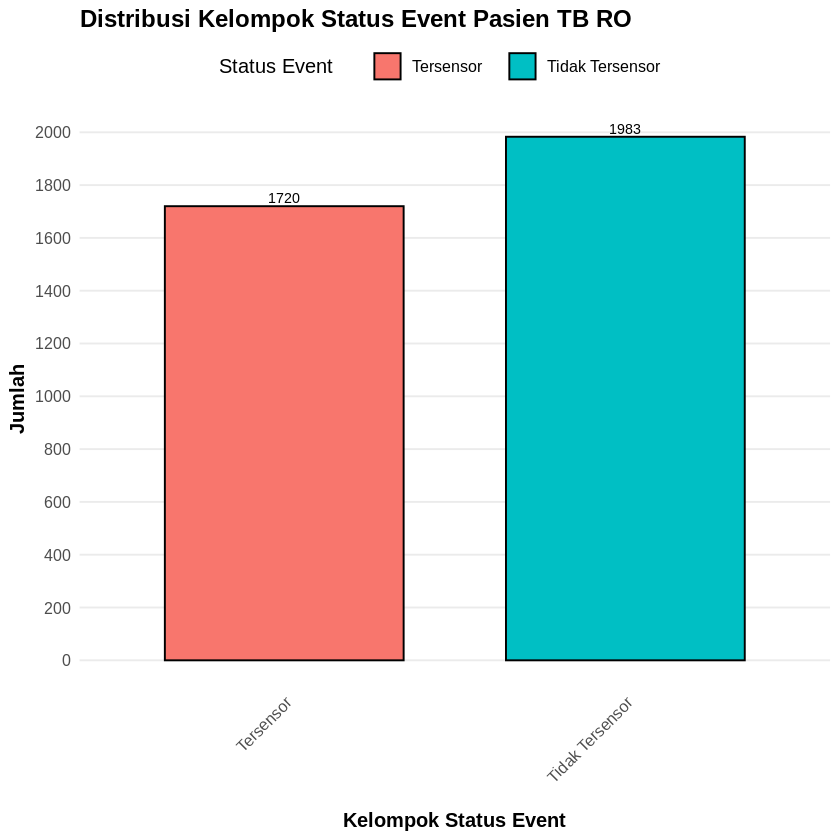

In [ ]:
ggplot(
  bismillah,
  aes(x = status_event, fill = status_event)
) +
  geom_bar(
    position = position_dodge(width = 0.8),
    width = 0.7,
    color = "black"
  ) +
  geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  ) +
  scale_y_continuous(
    breaks = seq(0, max(table(bismillah$status_event, bismillah$status_event)) + 50, by = 200)
  ) +
  labs(
    title = "Distribusi Kelompok Status Event Pasien TB RO",
    x = "Kelompok Status Event",
    y = "Jumlah",
    fill = "Status Event"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "top",
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank()
  )

## Umur

In [ ]:
library(dplyr)

bismillah$status_event_num <- as.numeric(bismillah$status_event) - 1

tabel_umur <- bismillah %>%
  group_by(umur) %>%
  summarise(
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    umur,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

tabel_umur

umur,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
>60 tahun,265,329,594 (16.04%),259.42,186
19-59 tahun,1646,1333,2979 (80.45%),313.46,269
10-18 tahun,69,57,126 (3.4%),314.67,255
0–9 tahun,3,1,4 (0.11%),292.25,278


In [ ]:
# Buat baris total
total_row <- bismillah %>%
  summarise(
    umur = "Total",
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    umur,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

# Gabungkan dengan tabel umur
tabel_umur_final <- bind_rows(tabel_umur, total_row)

tabel_umur_final

umur,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<chr>,<int>,<int>,<chr>,<dbl>,<dbl>
>60 tahun,265,329,594 (16.04%),259.42,186
19-59 tahun,1646,1333,2979 (80.45%),313.46,269
10-18 tahun,69,57,126 (3.4%),314.67,255
0–9 tahun,3,1,4 (0.11%),292.25,278
Total,1983,1720,3703 (100%),304.81,255


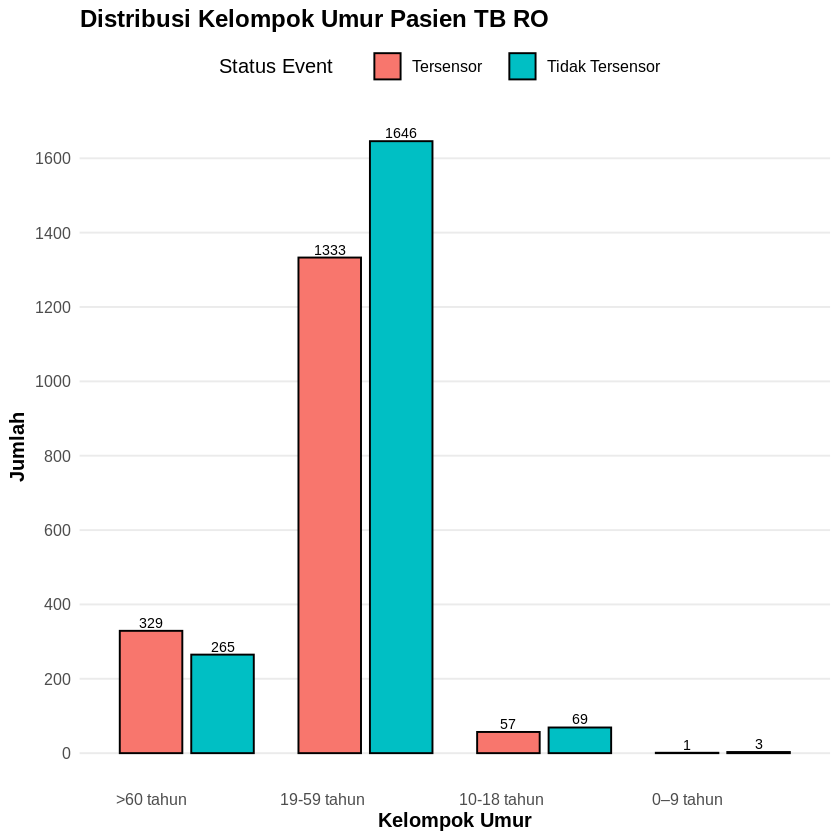

In [ ]:
ggplot(
  bismillah,
  aes(x = umur, fill = status_event)
) +
  geom_bar(
    position = position_dodge(width = 0.8),
    width = 0.7,
    color = "black"
  ) +
  geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  ) +
  scale_y_continuous(
    breaks = seq(0, max(table(bismillah$umur, bismillah$status_event)) + 50, by = 200)
  ) +
  labs(
    title = "Distribusi Kelompok Umur Pasien TB RO",
    x = "Kelompok Umur",
    y = "Jumlah",
    fill = "Status Event"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 1),
    legend.position = "top",
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank()
  )

## Jenis Kelamin

In [ ]:
tabel_jk <- bismillah %>%
  group_by(jk) %>%
  summarise(
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    jk,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

tabel_jk

jk,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
Perempuan,1150,1012,2162 (58.39%),303.85,252
Laki-laki,833,708,1541 (41.61%),306.15,260


In [ ]:
# Buat baris total
total_row <- bismillah %>%
  summarise(
    jk = "Total",
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    jk,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

# Gabungkan tabel per jenis kelamin dengan total
tabel_jk_final <- bind_rows(tabel_jk, total_row)

tabel_jk_final

jk,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<chr>,<int>,<int>,<chr>,<dbl>,<dbl>
Perempuan,1150,1012,2162 (58.39%),303.85,252
Laki-laki,833,708,1541 (41.61%),306.15,260
Total,1983,1720,3703 (100%),304.81,255


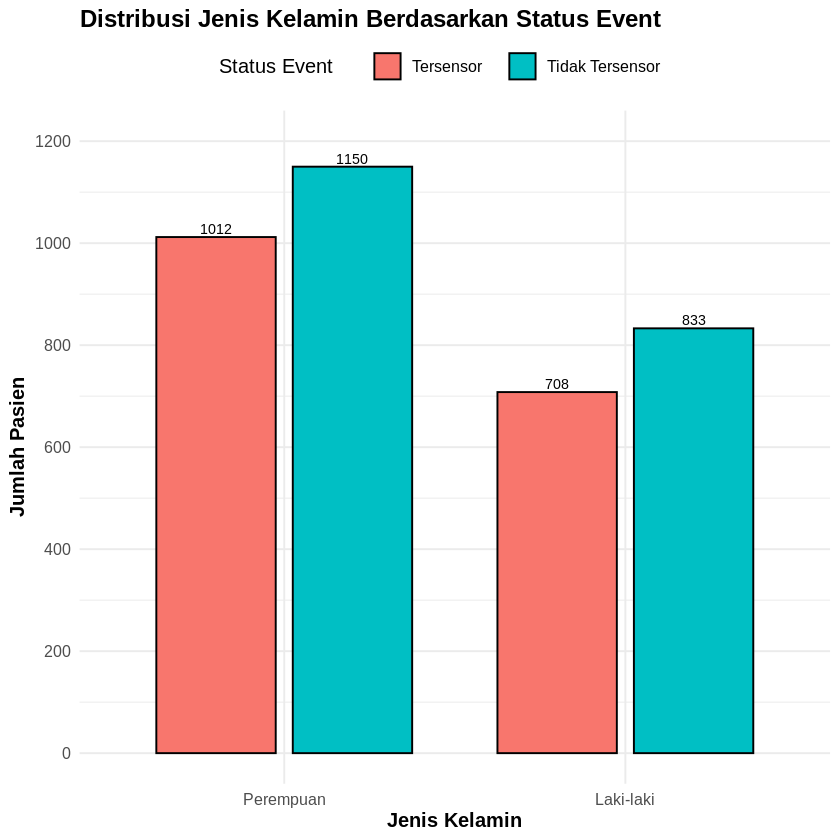

In [ ]:
max_y <- max(table(bismillah$jk, bismillah$status_event))

ggplot(bismillah, aes(x = jk, fill = status_event)) +
  geom_bar(
    position = position_dodge(width = 0.8),
    width = 0.7,
    color = "black"
  ) +
  geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  ) +
  scale_y_continuous(
    breaks = seq(0, max_y + 50, by = 200),
    limits = c(0, max_y + 50)
  ) +
  labs(
    title = "Distribusi Jenis Kelamin Berdasarkan Status Event",
    x = "Jenis Kelamin",
    y = "Jumlah Pasien",
    fill = "Status Event"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    legend.position = "top"
  )

## Faskes

In [ ]:
tabel_faskes <- bismillah %>%
  group_by(jenis_faskes) %>%
  summarise(
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    jenis_faskes,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

tabel_faskes

jenis_faskes,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
Puskesmas,87,80,167 (4.51%),151.05,171
Rumah Sakit,1896,1640,3536 (95.49%),312.07,269


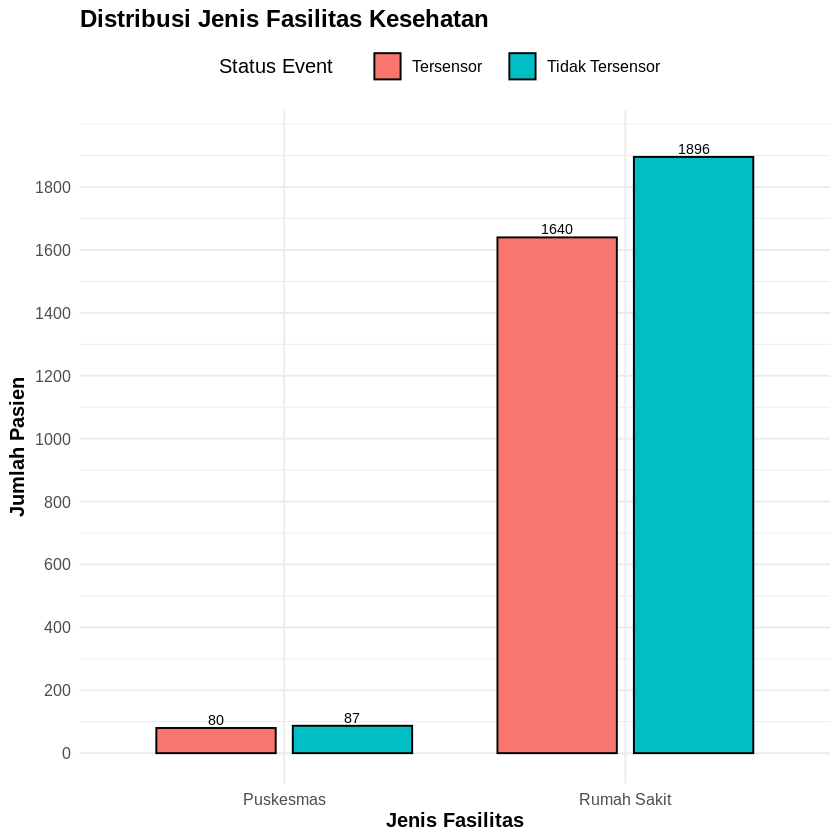

In [ ]:
max_y <- max(table(bismillah$jenis_faskes, bismillah$status_event))

ggplot(bismillah, aes(x = jenis_faskes, fill = status_event)) +
  geom_bar(
    position = position_dodge(width = 0.8),
    width = 0.7,
    color = "black"
  ) +
  geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  ) +
  scale_y_continuous(
    breaks = seq(0, max_y + 50, by = 200),
    limits = c(0, max_y + 50)
  ) +
  labs(
    title = "Distribusi Jenis Fasilitas Kesehatan",
    x = "Jenis Fasilitas",
    y = "Jumlah Pasien",
    fill = "Status Event"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    legend.position = "top"
  )

## Klasifikasi Anatomi

In [ ]:
tabel_anatomi <- bismillah %>%
  group_by(klasifikasi_anatomi) %>%
  summarise(
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    klasifikasi_anatomi,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

tabel_anatomi

klasifikasi_anatomi,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
TBC Ekstra Paru,10,7,17 (0.46%),298.94,191.0
TBC Paru,1973,1713,3686 (99.54%),304.83,255.5


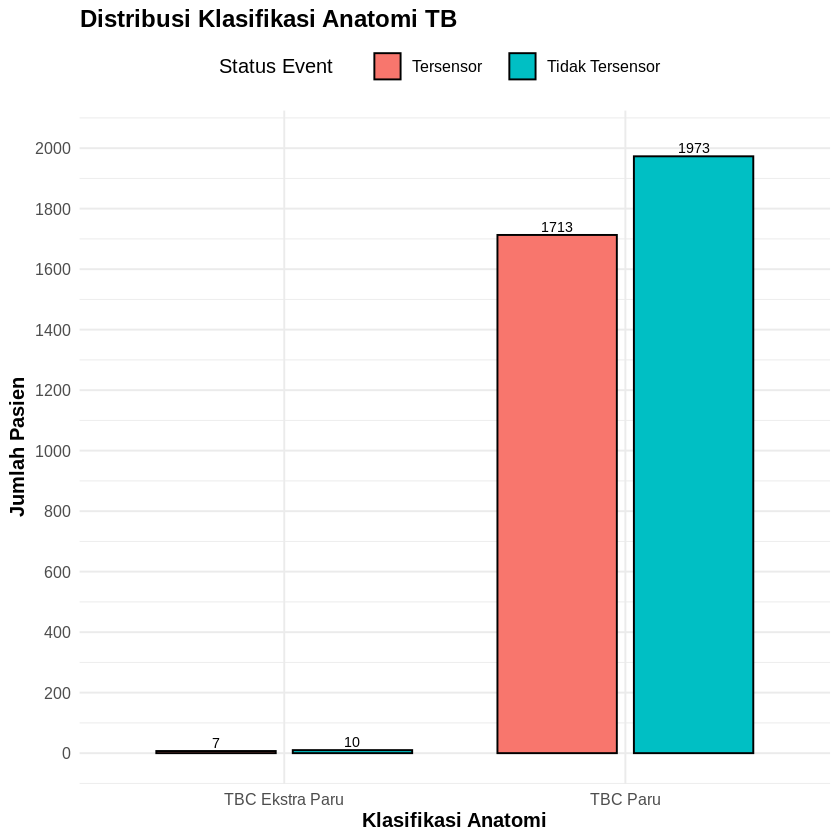

In [ ]:
max_y <- max(table(bismillah$klasifikasi_anatomi, bismillah$status_event))

ggplot(bismillah, aes(x = klasifikasi_anatomi, fill = status_event)) +
  geom_bar(
    position = position_dodge(width = 0.8),
    width = 0.7,
    color = "black"
  ) +
  geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  ) +
  scale_y_continuous(
    breaks = seq(0, max_y + 50, by = 200),
    limits = c(0, max_y + 50)
  ) +
  labs(
    title = "Distribusi Klasifikasi Anatomi TB",
    x = "Klasifikasi Anatomi",
    y = "Jumlah Pasien",
    fill = "Status Event"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    legend.position = "top"
  )

## Riwayat Pengobatan

In [ ]:
tabel_riwayat <- bismillah %>%
  group_by(r_obat) %>%
  summarise(
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    r_obat,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

tabel_riwayat

r_obat,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
Kambuh,385,315,700 (18.9%),311.94,260.5
Baru,1103,932,2035 (54.96%),305.67,263.0
Diobati setelah gagal,195,164,359 (9.69%),316.07,260.0
Diobati setelah putus berobat,75,86,161 (4.35%),295.32,208.0
"Pernah diobati, hasil tidak diketahui",225,223,448 (12.1%),284.12,214.5


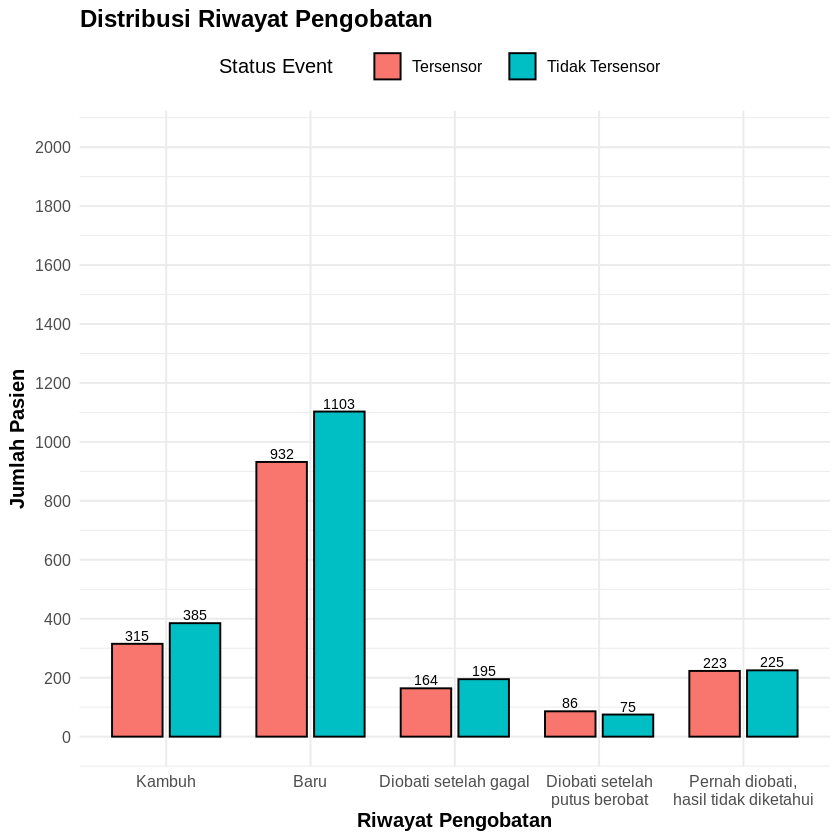

In [ ]:
ggplot(bismillah, aes(x = r_obat, fill = status_event)) +
  geom_bar(
    position = position_dodge(width = 0.8),
    width = 0.7,
    color = "black"
  ) +
  geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  ) +
  scale_y_continuous(
    breaks = seq(0, max_y + 50, by = 200),
    limits = c(0, max_y + 50)
  ) +
  labs(
    title = "Distribusi Riwayat Pengobatan",
    x = "Riwayat Pengobatan",
    y = "Jumlah Pasien",
    fill = "Status Event"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),  # teks datar
    legend.position = "top"
  )

## HIV

In [ ]:
tabel_hiv <- bismillah %>%
  group_by(hiv_status) %>%
  summarise(
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    hiv_status,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

tabel_hiv

hiv_status,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
ODHIV,34,58,92 (2.48%),264.07,208.5
Bukan ODHIV,1949,1662,3611 (97.52%),305.84,258.0


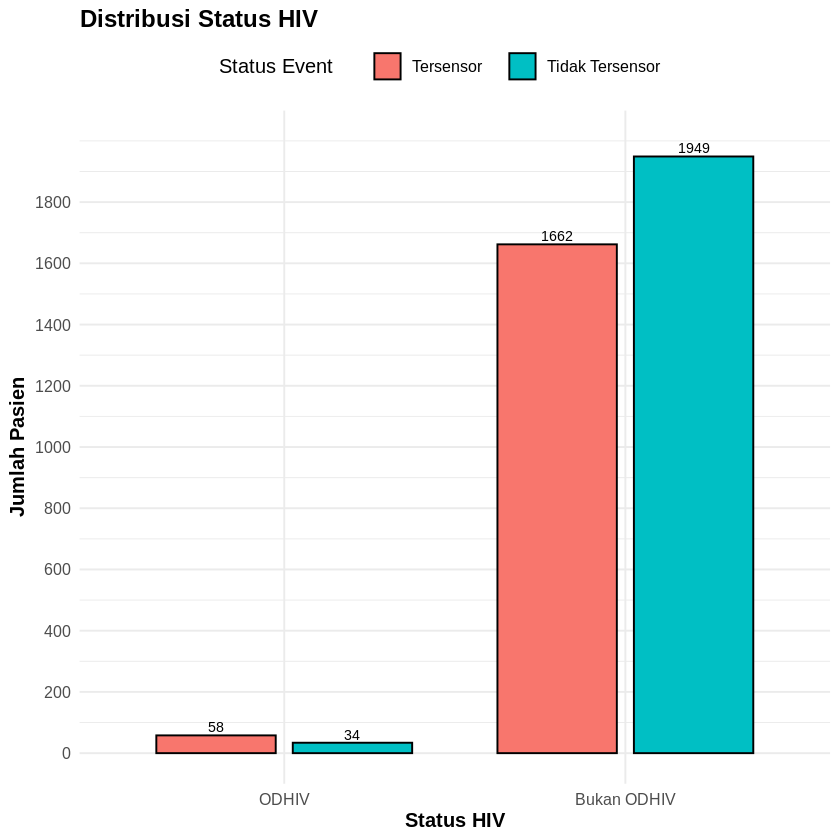

In [ ]:
max_y <- max(table(bismillah$hiv_status, bismillah$status_event))

ggplot(bismillah, aes(x = hiv_status, fill = status_event)) +
  geom_bar(
    position = position_dodge(width = 0.8),
    width = 0.7,
    color = "black"
  ) +
  geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  ) +
  scale_y_continuous(
    breaks = seq(0, max_y + 50, by = 200),
    limits = c(0, max_y + 50)
  ) +
  labs(
    title = "Distribusi Status HIV",
    x = "Status HIV",
    y = "Jumlah Pasien",
    fill = "Status Event"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    legend.position = "top"
  )

## DM

In [ ]:
tabel_dm <- bismillah %>%
  group_by(dm_riwayat) %>%
  summarise(
    `Tidak Tersensor` = sum(status_event_num == 1),
    `Tersensor` = sum(status_event_num == 0),
    Jumlah = n(),
    Persentase = round(100 * n() / nrow(bismillah), 2),
    Mean = round(mean(waktu, na.rm = TRUE), 2),
    Median = round(median(waktu, na.rm = TRUE), 2)
  ) %>%
  mutate(
    `Jumlah (Persentase)` = paste0(Jumlah, " (", Persentase, "%)")
  ) %>%
  select(
    dm_riwayat,
    `Tidak Tersensor`,
    `Tersensor`,
    `Jumlah (Persentase)`,
    Mean,
    Median
  )

tabel_dm

dm_riwayat,Tidak Tersensor,Tersensor,Jumlah (Persentase),Mean,Median
<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
Ya,675,645,1320 (35.65%),298.64,244
Tidak,1308,1075,2383 (64.35%),308.22,265


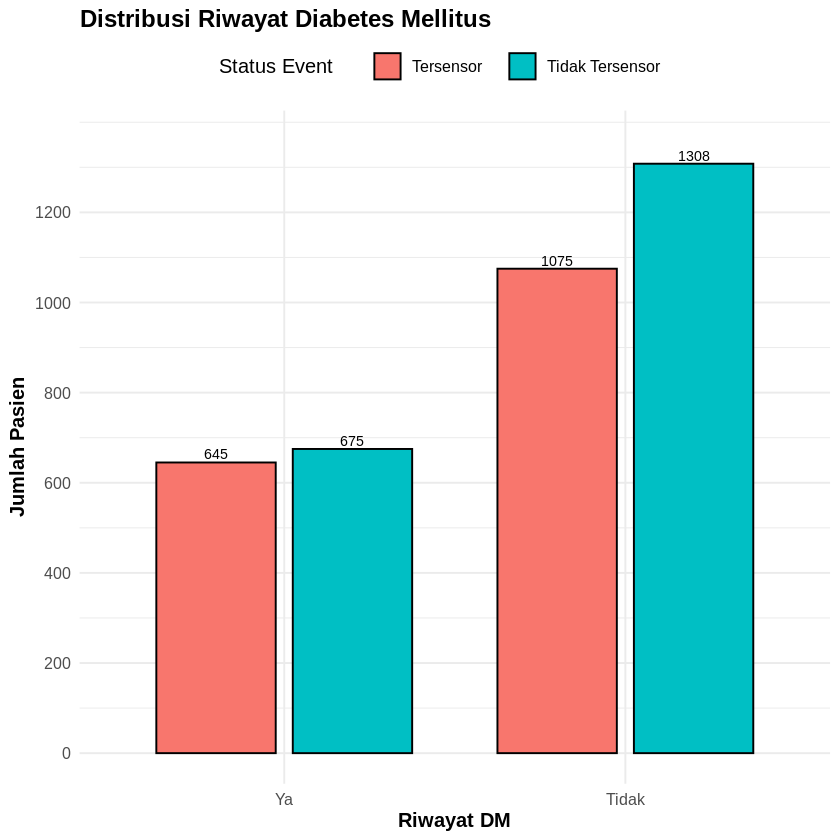

In [ ]:
max_y <- max(table(bismillah$dm_riwayat, bismillah$status_event))

ggplot(bismillah, aes(x = dm_riwayat, fill = status_event)) +
  geom_bar(
    position = position_dodge(width = 0.8),
    width = 0.7,
    color = "black"
  ) +
  geom_text(
    stat = "count",
    aes(label = ..count..),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  ) +
  scale_y_continuous(
    breaks = seq(0, max_y + 50, by = 200),
    limits = c(0, max_y + 50)
  ) +
  labs(
    title = "Distribusi Riwayat Diabetes Mellitus",
    x = "Riwayat DM",
    y = "Jumlah Pasien",
    fill = "Status Event"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    legend.position = "top"
  )

# **KURVA KAPLAN-MEIER DAN UJI LOG RANK**

H0 : tidak ada perbedaan antar tiap kelompok

H1 : ada perbedaan antar tiap kelompok

*(yang memenuhi uji log rank : ada perbedaan (tolak h0))

In [ ]:
install.packages("survminer")
install.packages("tidyverse")

library(dplyr)
library(tidyverse)
library(survival)
library(survminer)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘litedown’, ‘corrplot’, ‘car’, ‘markdown’, ‘png’, ‘jpeg’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘exactRankTests’, ‘mvtnorm’, ‘gridtext’, ‘ggpubr’, ‘gridExtra’, ‘maxstat’, ‘ggtext’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   

In [ ]:
bismillah = read.csv("/content/skripsi.csv", sep = ";")
head(bismillah)

,no_urut,umur,jk,healthcare,klasifikasi_anatomi,r_obat,hiv_status,dm_riwayat,waktu,status_event
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,2,1,0,1,2,1,1,68,0
2,2,2,0,1,1,1,1,1,74,0
3,5,3,0,0,1,0,1,1,167,1
4,6,2,0,0,1,2,1,1,167,1
5,10,3,1,0,1,2,1,1,167,0
6,11,2,0,0,1,2,1,1,167,1


## Umur

Ignoring unknown labels:
• colour : "Kelompok Umur"


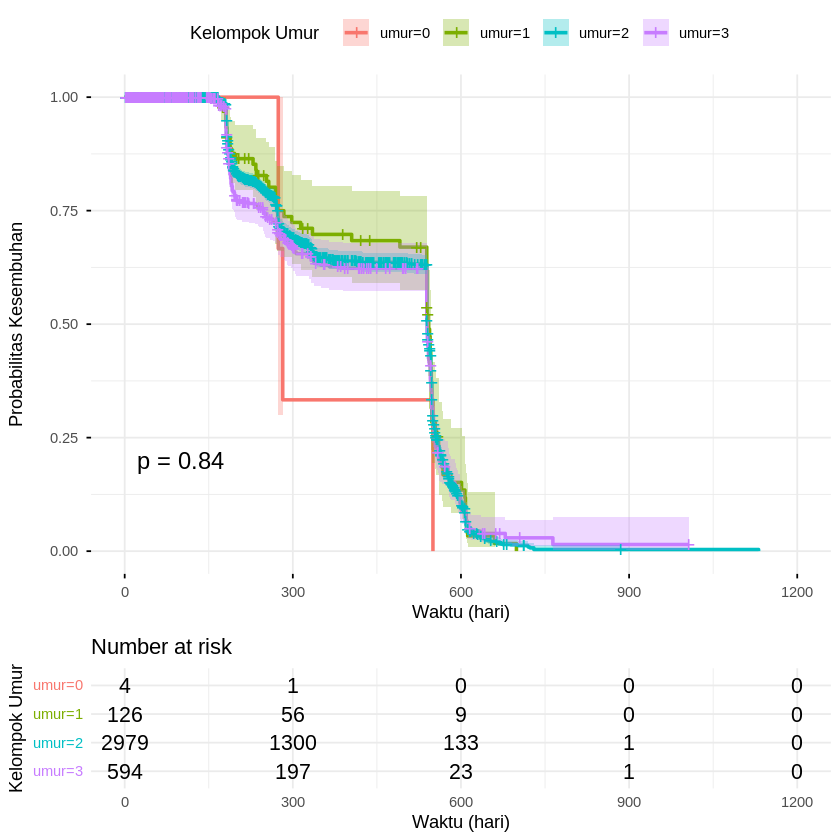

In [ ]:
fit_umur <- survfit(Surv(waktu, status_event == 1) ~ umur, data = bismillah)

ggsurvplot(
  fit_umur,
  data = bismillah,
  risk.table = TRUE,
  pval = TRUE,
  conf.int = TRUE,
  xlab = "Waktu (hari)",
  ylab = "Probabilitas Kesembuhan",
  legend.title = "Kelompok Umur",
  ggtheme = theme_minimal()
)

### Detail Uji Log Rank

In [ ]:
logrank_u <- survdiff(Surv(waktu, status_event) ~ umur, data = bismillah)

logrank_u

Call:
survdiff(formula = Surv(waktu, status_event) ~ umur, data = bismillah)

          N Observed Expected (O-E)^2/E (O-E)^2/V
umur=0    4        3     1.88   0.66713    0.7016
umur=1  126       69    71.59   0.09398    0.1031
umur=2 2979     1646  1648.14   0.00279    0.0175
umur=3  594      265   261.38   0.05010    0.0610

 Chisq= 0.9  on 3 degrees of freedom, p= 0.8 

pvalue : gagal tolak h0 --> tidak ada perbedaan antara kurva di tiap umurnya (laju kesembuhannya sama)

## Jenis Kelamin

Ignoring unknown labels:
• colour : "Jenis Kelamin"


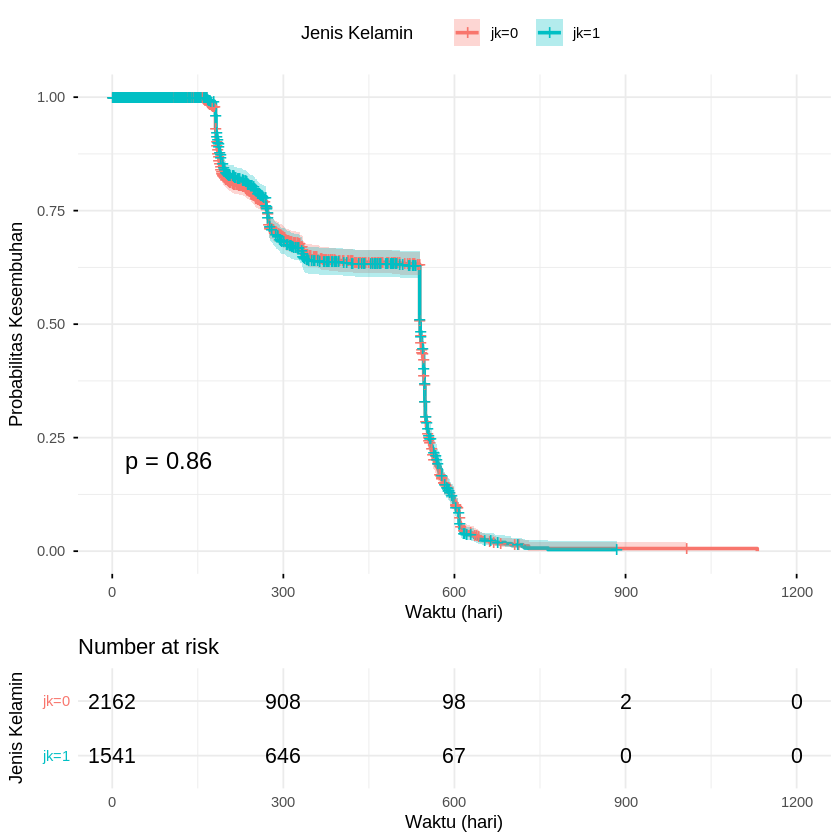

In [ ]:
fit_jk <- survfit(Surv(waktu, status_event == 1) ~ jk, data = bismillah)

ggsurvplot(
  fit_jk,
  data = bismillah,
  risk.table = TRUE,
  pval = TRUE,
  conf.int = TRUE,
  xlab = "Waktu (hari)",
  ylab = "Probabilitas Kesembuhan",
  legend.title = "Jenis Kelamin",
  ggtheme = theme_minimal()
)

### Detail Uji Log Rank

In [ ]:
logrank_jk <- survdiff(Surv(waktu, status_event) ~ jk, data = bismillah)

logrank_jk

Call:
survdiff(formula = Surv(waktu, status_event) ~ jk, data = bismillah)

        N Observed Expected (O-E)^2/E (O-E)^2/V
jk=0 2162     1150     1146    0.0123    0.0307
jk=1 1541      833      837    0.0168    0.0307

 Chisq= 0  on 1 degrees of freedom, p= 0.9 

pvalue : gagal tolak h0 --> tidak ada perbedaan antara kurva di tiap jenis kelamin (laju kesembuhannya sama)

## Jenis Faskes

Ignoring unknown labels:
• colour : "Healthcare Facility"


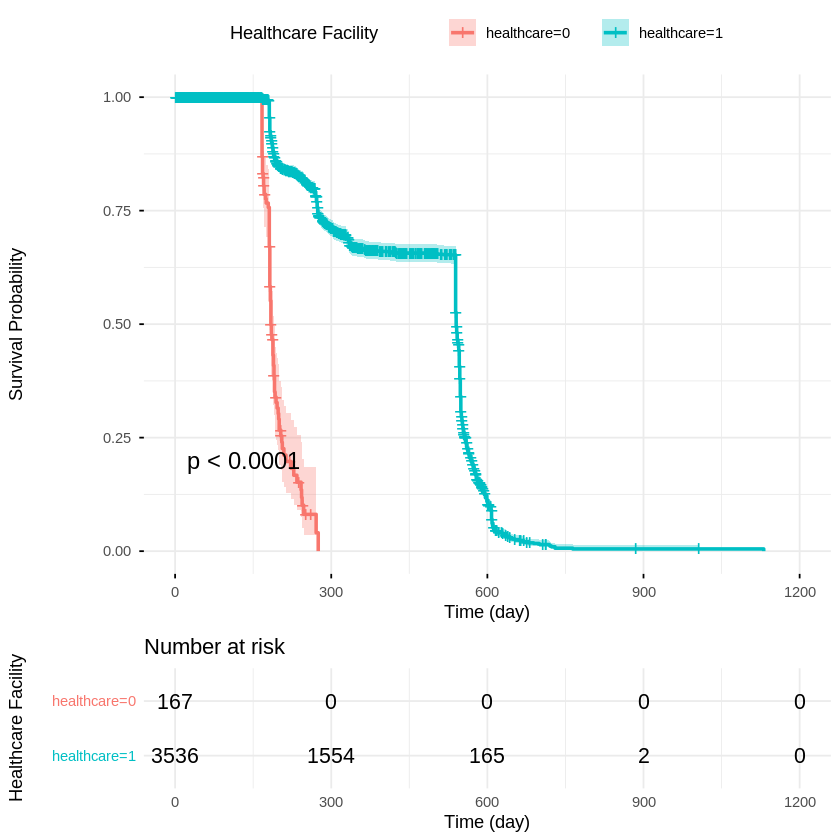

In [ ]:
fit_faskes <- survfit(Surv(waktu, status_event == 1) ~ healthcare, data = bismillah)

ggsurvplot(
  fit_faskes,
  data = bismillah,
  risk.table = TRUE,
  pval = TRUE,
  conf.int = TRUE,
  xlab = "Time (day)",
  ylab = "Survival Probability",
  legend.title = "Healthcare Facility",
  ggtheme = theme_minimal()
)

### Detail Uji Log Rank

In [ ]:
logrank_faskes <- survdiff(Surv(waktu, status_event) ~ jenis_faskes, data = bismillah)

logrank_faskes

Call:
survdiff(formula = Surv(waktu, status_event) ~ jenis_faskes, 
    data = bismillah)

                  N Observed Expected (O-E)^2/E (O-E)^2/V
jenis_faskes=0  167       87     11.9    475.61       498
jenis_faskes=1 3536     1896   1971.1      2.86       498

 Chisq= 498  on 1 degrees of freedom, p= <2e-16 

pvalue : tolak h0 --> ada perbedaan antara kurva di tiap faskes (laju kesembuhannya beda)

## Klasifikasi Anatomi

Ignoring unknown labels:
• colour : "Klasifikasi Anatomi"


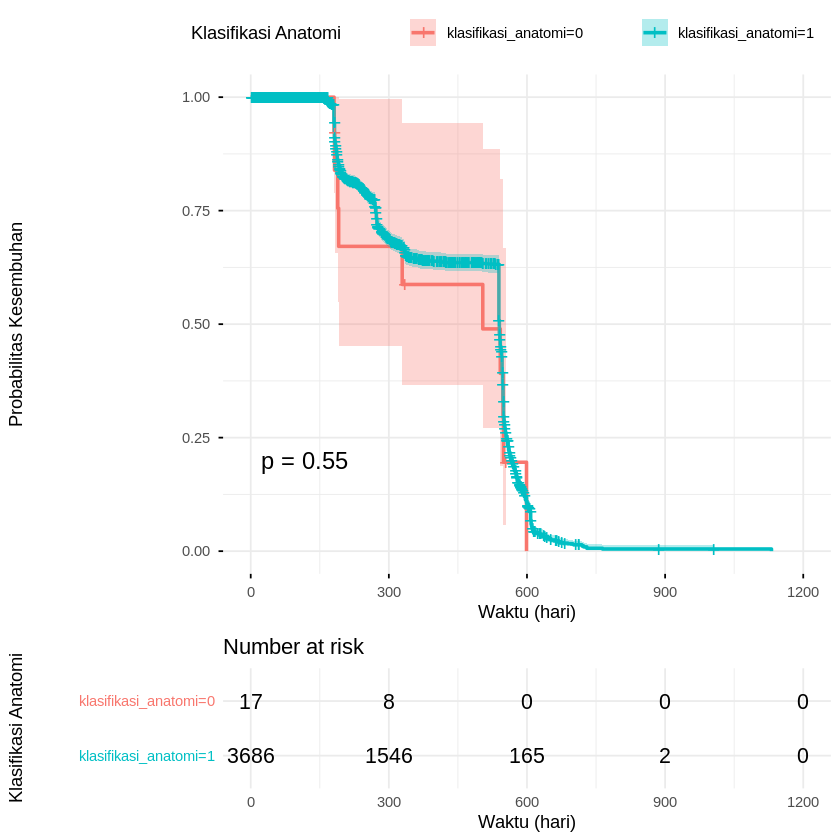

In [ ]:
fit_anatomi <- survfit(Surv(waktu, status_event == 1) ~ klasifikasi_anatomi, data = bismillah)

ggsurvplot(
  fit_anatomi,
  data = bismillah,
  risk.table = TRUE,
  pval = TRUE,
  conf.int = TRUE,
  xlab = "Waktu (hari)",
  ylab = "Probabilitas Kesembuhan",
  legend.title = "Klasifikasi Anatomi",
  ggtheme = theme_minimal()
)

### Detail Uji Log Rank

In [ ]:
logrank_anatomi <- survdiff(Surv(waktu, status_event) ~ klasifikasi_anatomi, data = bismillah)

logrank_anatomi

Call:
survdiff(formula = Surv(waktu, status_event) ~ klasifikasi_anatomi, 
    data = bismillah)

                         N Observed Expected (O-E)^2/E (O-E)^2/V
klasifikasi_anatomi=0   17       10     8.31   0.34298     0.363
klasifikasi_anatomi=1 3686     1973  1974.69   0.00144     0.363

 Chisq= 0.4  on 1 degrees of freedom, p= 0.5 

pvalue : gagal tolak h0 --> tidak ada perbedaan antara kurva di tiap anatomi (laju kesembuhannya sama)

## Riwayat Pengobatan

Ignoring unknown labels:
• colour : "Riwayat Obat"


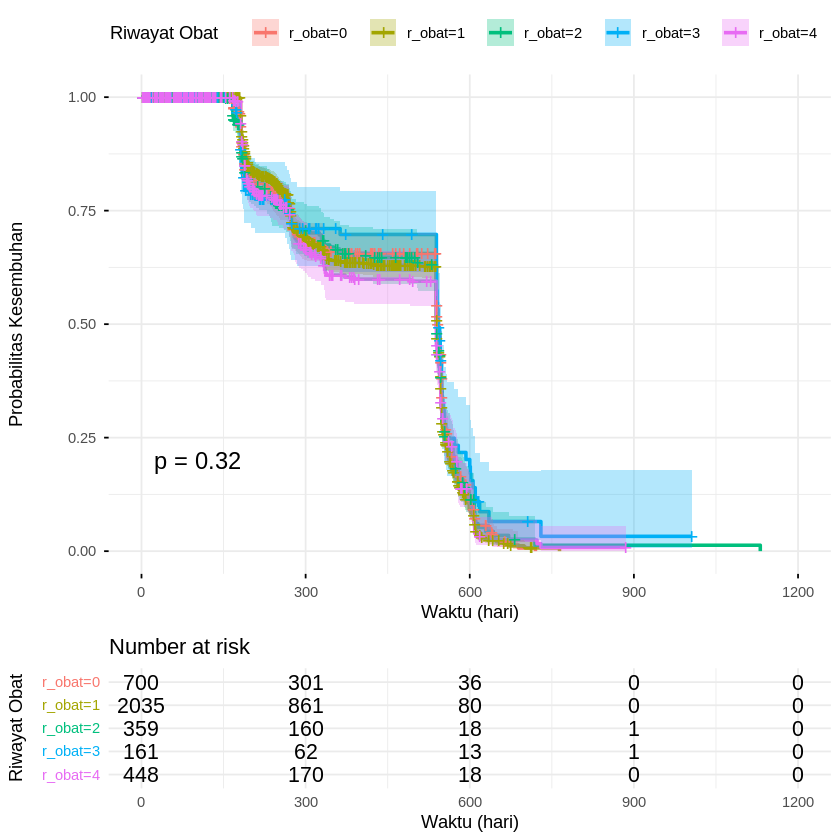

In [ ]:
fit_riwayat <- survfit(Surv(waktu, status_event == 1) ~ r_obat, data = bismillah)

ggsurvplot(
  fit_riwayat,
  data = bismillah,
  risk.table = TRUE,
  pval = TRUE,
  conf.int = TRUE,
  xlab = "Waktu (hari)",
  ylab = "Probabilitas Kesembuhan",
  legend.title = "Riwayat Obat",
  ggtheme = theme_minimal()
)

### Detail Uji Log Rank

In [ ]:
logrank_rp <- survdiff(Surv(waktu, status_event) ~ r_obat, data = bismillah)

logrank_rp

Call:
survdiff(formula = Surv(waktu, status_event) ~ r_obat, data = bismillah)

            N Observed Expected (O-E)^2/E (O-E)^2/V
r_obat=0  700      385    402.9    0.7919    1.0513
r_obat=1 2035     1103   1075.0    0.7303    1.6897
r_obat=2  359      195    197.2    0.0251    0.0296
r_obat=3  161       75     90.5    2.6466    2.9532
r_obat=4  448      225    217.5    0.2616    0.3101

 Chisq= 4.7  on 4 degrees of freedom, p= 0.3 

pvalue : gagal tolak h0 --> tidak ada perbedaan antara kurva di tiap riwayat (laju kesembuhannya sama)

## Status HIV

Ignoring unknown labels:
• colour : "Status HIV"


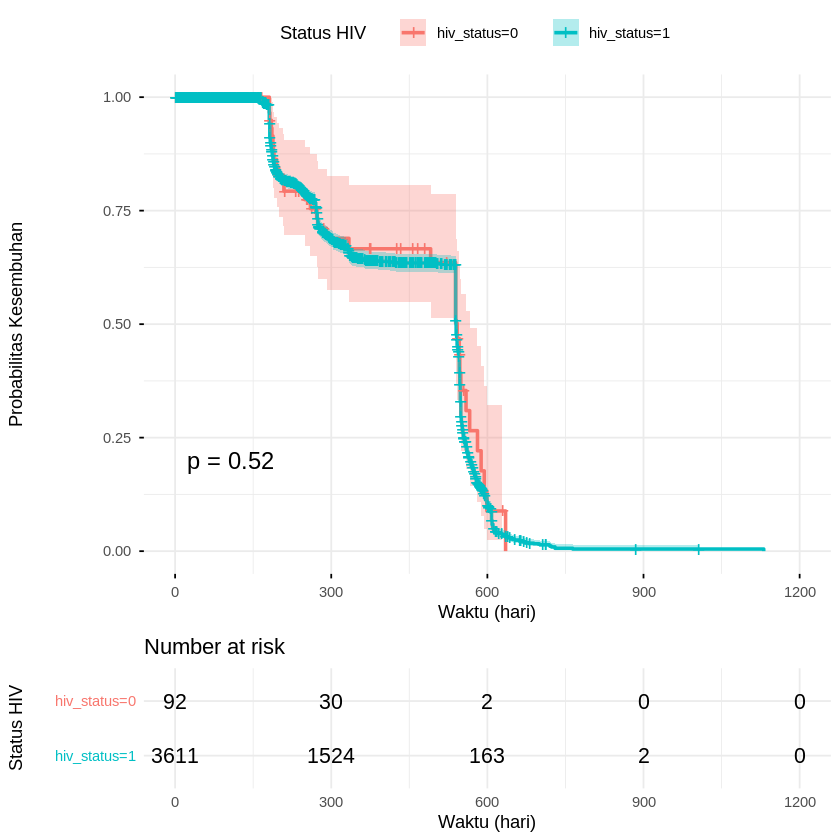

In [ ]:
fit_hiv <- survfit(Surv(waktu, status_event == 1) ~ hiv_status, data = bismillah)

ggsurvplot(
  fit_hiv,
  data = bismillah,
  risk.table = TRUE,
  pval = TRUE,
  conf.int = TRUE,
  xlab = "Waktu (hari)",
  ylab = "Probabilitas Kesembuhan",
  legend.title = "Status HIV",
  ggtheme = theme_minimal()
)

### Detail Uji Log Rank

In [ ]:
logrank_hiv <- survdiff(Surv(waktu, status_event) ~ hiv_status, data = bismillah)

logrank_hiv

Call:
survdiff(formula = Surv(waktu, status_event) ~ hiv_status, data = bismillah)

                N Observed Expected (O-E)^2/E (O-E)^2/V
hiv_status=0   92       34     37.8   0.38120     0.408
hiv_status=1 3611     1949   1945.2   0.00741     0.408

 Chisq= 0.4  on 1 degrees of freedom, p= 0.5 

pvalue : tolak h0 --> ada perbedaan antara kurva di tiap hiv (laju kesembuhannya beda)

## DM Riwayat

Ignoring unknown labels:
• colour : "Riwayat DM"


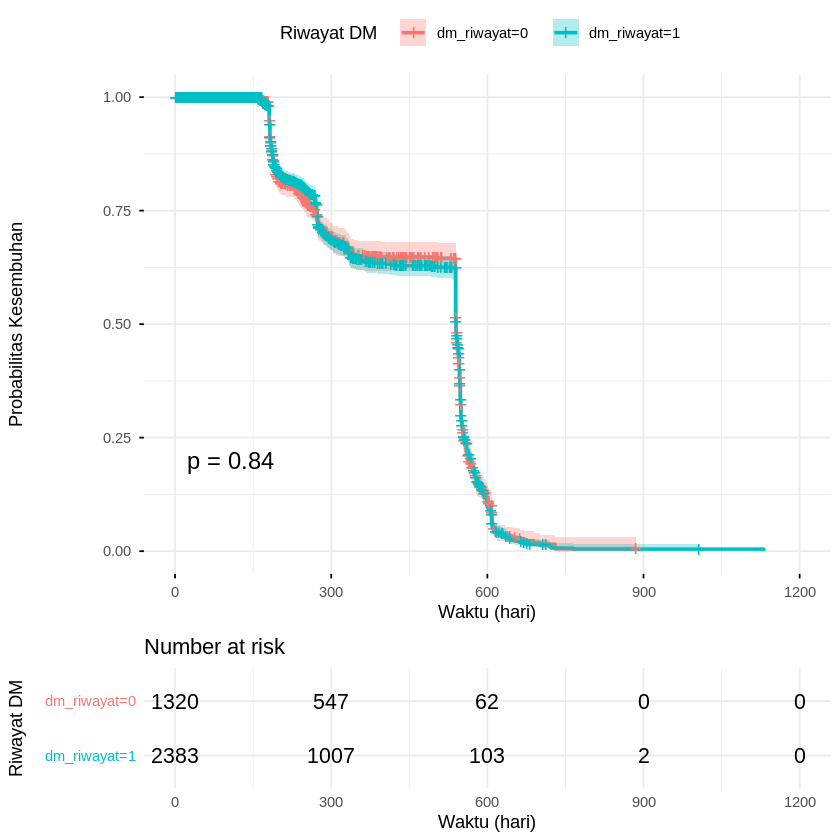

In [ ]:
fit_dm <- survfit(Surv(waktu, status_event == 1) ~ dm_riwayat, data = bismillah)

ggsurvplot(
  fit_dm,
  data = bismillah,
  risk.table = TRUE,
  pval = TRUE,
  conf.int = TRUE,
  xlab = "Waktu (hari)",
  ylab = "Probabilitas Kesembuhan",
  legend.title = "Riwayat DM",
  ggtheme = theme_minimal()
)

### Detail Uji Log Rank

In [ ]:
logrank_dm <- survdiff(Surv(waktu, status_event) ~ dm_riwayat, data = bismillah)

logrank_dm

Call:
survdiff(formula = Surv(waktu, status_event) ~ dm_riwayat, data = bismillah)

                N Observed Expected (O-E)^2/E (O-E)^2/V
dm_riwayat=0 1320      675      679    0.0268    0.0431
dm_riwayat=1 2383     1308     1304    0.0140    0.0431

 Chisq= 0  on 1 degrees of freedom, p= 0.8 

pvalue : gagal tolak h0 --> tidak ada perbedaan antara kurva di tiap dm (laju kesembuhannya sama)

# **SURVIVAL ANALYSIS**

In [ ]:
# install.packages("survminer")
# install.packages("tidyverse")

# library(dplyr)
# library(tidyverse)
# library(survival)
# library(survminer)

In [ ]:
# Umur
bismillah$umur <- factor(
  bismillah$umur,
  levels = c(3,2,1,0),
  labels = c(
    ">60 tahun",
    "19-59 tahun",
    "10-18 tahun",
    "0–9 tahun"
  )
)

# Jenis kelamin
bismillah$jk <- factor(
  bismillah$jk,
  levels = c(0,1),
  labels = c("Perempuan", "Laki-laki")
)

# Jenis fasilitas kesehatan
bismillah$jenis_faskes <- factor(
  bismillah$jenis_faskes,
  levels = c(0, 1),
  labels = c("Puskesmas", "Rumah Sakit")
)

# Klasifikasi anatomi
bismillah$klasifikasi_anatomi <- factor(
  bismillah$klasifikasi_anatomi,
  levels = c(0,1),
  labels = c("TBC Ekstra Paru", "TBC Paru")
)

# Riwayat pengobatan
bismillah$r_obat <- factor(
  bismillah$r_obat,
  levels = c(0,1,2,3,4),
  labels = c(
    "Kambuh",
    "Baru",
    "Diobati setelah gagal",
    "Diobati setelah putus berobat",
    "Pernah diobati tidak diketahui hasilnya / Tidak diketahui"
  )
)

# Status HIV
bismillah$hiv_status <- factor(
  bismillah$hiv_status,
  levels = c(0,1),
  labels = c("ODHIV", "Bukan ODHIV")
)

# Diabetes Mellitus (DM)
bismillah$dm_riwayat <- factor(
  bismillah$dm_riwayat,
  levels = c(0,1),
  labels = c("Ya", "Tidak")
)

In [ ]:
colSums(is.na(bismillah))

no_urut                umur                  jk        jenis_faskes 
                  0                   0                   0                   0 
klasifikasi_anatomi              r_obat          hiv_status          dm_riwayat 
                  0                   0                   0                   0 
              waktu        status_event 
                  0                   0

In [ ]:
cox_model <- coxph(Surv(waktu, status_event==1) ~ umur + jk + jenis_faskes + klasifikasi_anatomi + r_obat + dm_riwayat + hiv_status,
                   data = bismillah)
summary(cox_model)

Call:
coxph(formula = Surv(waktu, status_event == 1) ~ umur + jk + 
    jenis_faskes + klasifikasi_anatomi + r_obat + dm_riwayat + 
    hiv_status, data = bismillah)

  n= 3703, number of events= 1983 

                                                                      coef
umur19-59 tahun                                                 -0.0322595
umur10-18 tahun                                                 -0.0702667
umur0–9 tahun                                                    0.4689287
jkLaki-laki                                                     -0.0181936
jenis_faskesRumah Sakit                                         -2.2067245
klasifikasi_anatomiTBC Paru                                     -0.2879425
r_obatBaru                                                       0.0980401
r_obatDiobati setelah gagal                                      0.0548602
r_obatDiobati setelah putus berobat                             -0.1314272
r_obatPernah diobati tidak diketahui hasilnya /

## Uji Asumsi PH

In [ ]:
cox.zph(cox_model)

                      chisq df     p
umur                 4.0553  3 0.256
jk                   1.4375  1 0.231
jenis_faskes         3.2634  1 0.071
klasifikasi_anatomi  0.0689  1 0.793
r_obat              10.5735  4 0.032
dm_riwayat           0.5481  1 0.459
hiv_status           0.2558  1 0.613
GLOBAL              18.2420 12 0.109

yg tidak memenuhi asumsi adalah riwayat pengobatan

## Uji Cox PH

In [ ]:
cox_ph <- coxph(Surv(waktu, status_event==1) ~ umur + jk + jenis_faskes + klasifikasi_anatomi + hiv_status + dm_riwayat,
                   data = bismillah)
summary(cox_ph)

Call:
coxph(formula = Surv(waktu, status_event == 1) ~ umur + jk + 
    jenis_faskes + klasifikasi_anatomi + hiv_status + dm_riwayat, 
    data = bismillah)

  n= 3703, number of events= 1983 

                                 coef exp(coef)  se(coef)       z Pr(>|z|)    
umur19-59 tahun             -0.010137  0.989914  0.067028  -0.151    0.880    
umur10-18 tahun             -0.027235  0.973133  0.137856  -0.198    0.843    
umur0–9 tahun                0.505608  1.657993  0.581869   0.869    0.385    
jkLaki-laki                 -0.016454  0.983681  0.046014  -0.358    0.721    
jenis_faskesRumah Sakit     -2.202282  0.110551  0.118516 -18.582   <2e-16 ***
klasifikasi_anatomiTBC Paru -0.234115  0.791271  0.318117  -0.736    0.462    
hiv_statusBukan ODHIV        0.064675  1.066812  0.174159   0.371    0.710    
dm_riwayatTidak              0.002676  1.002680  0.048351   0.055    0.956    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                           

## Uji Stratified

### Membuat Variabel Stratifikasi Z

In [ ]:
strata(bismillah$r_obat)

[1] Diobati setelah gagal                                    
   [2] Baru                                                     
   [3] Kambuh                                                   
   [4] Diobati setelah gagal                                    
   [5] Diobati setelah gagal                                    
   [6] Diobati setelah gagal                                    
   [7] Diobati setelah gagal                                    
   [8] Kambuh                                                   
   [9] Diobati setelah gagal                                    
  [10] Diobati setelah gagal                                    
  [11] Kambuh                                                   
  [12] Diobati setelah gagal                                    
  [13] Baru                                                     
  [14] Baru                                                     
  [15] Baru                                                     
  [16] Diobati setelah gagal                                    
  [17] Baru                                                     
  [18] Baru                                                     
  [19] Baru                                                     
  [20] Kambuh                                                   
  [21] Kambuh                                                   
  [22] Kambuh                                                   
  [23] Baru                                                     
  [24] Baru                                                     
  [25] Kambuh                                                   
  [26] Kambuh                                                   
  [27] Baru                                                     
  [28] Baru                                                     
  [29] Kambuh                                                   
  [30] Baru                                                     
  [31] Kambuh                                                   
  [32] Baru                                                     
  [33] Baru                                                     
  [34] Baru                                                     
  [35] Kambuh                                                   
  [36] Kambuh                                                   
  [37] Baru                                                     
  [38] Baru                                                     
  [39] Kambuh                                                   
  [40] Baru                                                     
  [41] Diobati setelah gagal                                    
  [42] Pernah diobati tidak diketahui hasilnya / Tidak diketahui
  [43] Baru                                                     
  [44] Diobati setelah gagal                                    
  [45] Kambuh                                                   
  [46] Diobati setelah gagal                                    
  [47] Baru                                                     
  [48] Diobati setelah gagal                                    
  [49] Baru                                                     
  [50] Diobati setelah gagal                                    
  [51] Baru                                                     
  [52] Baru                                                     
  [53] Baru                                                     
  [54] Baru                                                     
  [55] Baru                                                     
  [56] Kambuh                                                   
  [57] Baru                                                     
  [58] Baru                                                     
  [59] Baru                                                     
  [60] Kambuh                                                   
  [61] Kambuh                                                   
  [62] Pernah diobati tidak diketahui 

### Tanpa Interaksi

In [ ]:
tanpa_interaksi_z <- coxph(
  Surv(waktu, status_event == 1) ~
    umur + jk + jenis_faskes + klasifikasi_anatomi +
    hiv_status + dm_riwayat +
    strata(r_obat),
  data = bismillah,
  method = "breslow"
)
summary(tanpa_interaksi_z)

Call:
coxph(formula = Surv(waktu, status_event == 1) ~ umur + jk + 
    jenis_faskes + klasifikasi_anatomi + hiv_status + dm_riwayat + 
    strata(r_obat), data = bismillah, method = "breslow")

  n= 3703, number of events= 1983 

                                coef exp(coef) se(coef)       z Pr(>|z|)    
umur19-59 tahun             -0.03942   0.96135  0.06797  -0.580    0.562    
umur10-18 tahun             -0.08243   0.92088  0.13915  -0.592    0.554    
umur0–9 tahun                0.46145   1.58638  0.58229   0.792    0.428    
jkLaki-laki                 -0.01403   0.98607  0.04609  -0.304    0.761    
jenis_faskesRumah Sakit     -2.13385   0.11838  0.11990 -17.797   <2e-16 ***
klasifikasi_anatomiTBC Paru -0.28646   0.75091  0.32084  -0.893    0.372    
hiv_statusBukan ODHIV        0.02303   1.02329  0.17499   0.132    0.895    
dm_riwayatTidak             -0.00398   0.99603  0.04883  -0.082    0.935    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

        

### Dengan Interaksi

In [ ]:
interaksi_z = coxph(Surv(waktu, status_event==1) ~
      umur + jk + jenis_faskes + klasifikasi_anatomi + hiv_status + dm_riwayat +
      umur:r_obat + jk:r_obat + jenis_faskes:r_obat +
      klasifikasi_anatomi:r_obat + hiv_status:r_obat + dm_riwayat:r_obat +
      strata(r_obat),
      data=bismillah, method = "breslow")
summary(interaksi_z)

Call:
coxph(formula = Surv(waktu, status_event == 1) ~ umur + jk + 
    jenis_faskes + klasifikasi_anatomi + hiv_status + dm_riwayat + 
    umur:r_obat + jk:r_obat + jenis_faskes:r_obat + klasifikasi_anatomi:r_obat + 
    hiv_status:r_obat + dm_riwayat:r_obat + strata(r_obat), data = bismillah, 
    method = "breslow")

  n= 3703, number of events= 1983 

                                                                                                  coef
umur19-59 tahun                                                                             -1.023e-01
umur10-18 tahun                                                                              7.503e-01
umur0–9 tahun                                                                                1.228e+00
jkLaki-laki                                                                                  4.959e-02
jenis_faskesRumah Sakit                                                                     -2.306e+00
klasifikasi_anatomiTBC P

In [ ]:
anova(tanpa_interaksi_z, interaksi_z, test = "LRT")

,loglik,Chisq,Df,Pr(>|Chi|)
,<dbl>,<dbl>,<int>,<dbl>
1,-11009.19,NA,NA,NA
2,-10994.37,29.64606,28,0.3803332


gagal tolak, brrti tidak ada interaksi

## Uji Extended Cox

## g1(t) = t

### mengubah format data menjadi format counting process

In [ ]:
bismillah.cp <- survSplit(
  data   = bismillah,
  cut    = bismillah$waktu[bismillah$status_event == 1],
  start  = "start",
  end    = "waktu",
  event  = "status_event",
  id     = "id"
)

In [ ]:
nrow(bismillah.cp)

[1] 337021

### membuat variabel interaksi antara fungsi waktu dengan variabel yang tidak memenuhi asumsi ph (dm dan riwayat pengobatan)

In [ ]:
dummy_riwayat <- model.matrix(~ r_obat, data = bismillah.cp)[,-1]
bismillah.cp <- cbind(bismillah.cp, dummy_riwayat)

In [ ]:
for(i in colnames(dummy_riwayat)){
  bismillah.cp[[paste0("t_", i)]] <-
    bismillah.cp[[i]] * bismillah.cp$waktu
}

In [ ]:
colnames(bismillah.cp)

[1] "no_urut"                                                          
 [2] "umur"                                                             
 [3] "jk"                                                               
 [4] "jenis_faskes"                                                     
 [5] "klasifikasi_anatomi"                                              
 [6] "r_obat"                                                           
 [7] "hiv_status"                                                       
 [8] "dm_riwayat"                                                       
 [9] "id"                                                               
[10] "start"                                                            
[11] "waktu"                                                            
[12] "status_event"                                                     
[13] "r_obatBaru"                                                       
[14] "r_obatDiobati setelah gagal"                                      
[15] "r_obatDiobati setelah putus berobat"                              
[16] "r_obatPernah diobati tidak diketahui hasilnya / Tidak diketahui"  
[17] "t_r_obatBaru"                                                     
[18] "t_r_obatDiobati setelah gagal"                                    
[19] "t_r_obatDiobati setelah putus berobat"                            
[20] "t_r_obatPernah diobati tidak diketahui hasilnya / Tidak diketahui"

In [ ]:
model_t <- coxph(
  Surv(start, waktu, status_event) ~
    umur +
    jk +
    jenis_faskes +
    klasifikasi_anatomi +
    hiv_status +
    r_obat +
    dm_riwayat +
    `t_r_obatBaru` +
    `t_r_obatDiobati setelah gagal` +
    `t_r_obatDiobati setelah putus berobat` +
    `t_r_obatPernah diobati tidak diketahui hasilnya / Tidak diketahui` +
    cluster(id),
  data = bismillah.cp
)

summary(model_t)

Call:
coxph(formula = Surv(start, waktu, status_event) ~ umur + jk + 
    jenis_faskes + klasifikasi_anatomi + hiv_status + r_obat + 
    dm_riwayat + t_r_obatBaru + `t_r_obatDiobati setelah gagal` + 
    `t_r_obatDiobati setelah putus berobat` + `t_r_obatPernah diobati tidak diketahui hasilnya / Tidak diketahui`, 
    data = bismillah.cp, cluster = id)

  n= 337021, number of events= 1983 

                                                                          coef
umur19-59 tahun                                                     -0.0360320
umur10-18 tahun                                                     -0.0773333
umur0–9 tahun                                                        0.4669712
jkLaki-laki                                                         -0.0182462
jenis_faskesRumah Sakit                                             -2.2027318
klasifikasi_anatomiTBC Paru                                         -0.2798155
hiv_statusBukan ODHIV                               

## g2(t) = In(t)

### mengubah format data menjadi format counting process

In [ ]:
bismillah.cp <- survSplit(
  data   = bismillah,
  cut    = bismillah$waktu[bismillah$status_event == 1],
  start  = "start",
  end    = "waktu",
  event  = "status_event",
  id     = "id"
)

### membuat variabel interaksi antara fungsi waktu dengan variabel yang tidak memenuhi asumsi ph (dm dan riwayat pengobatan)

In [ ]:
dummy_riwayat <- model.matrix(~ r_obat, data = bismillah.cp)[,-1]
bismillah.cp <- cbind(bismillah.cp, dummy_riwayat)

In [ ]:
for(i in colnames(dummy_riwayat)){
  bismillah.cp[[paste0("logt_", i)]] <-
    bismillah.cp[[i]] * log(bismillah.cp$waktu)
}

In [ ]:
colnames(bismillah.cp)

[1] "no_urut"                                                             
 [2] "umur"                                                                
 [3] "jk"                                                                  
 [4] "jenis_faskes"                                                        
 [5] "klasifikasi_anatomi"                                                 
 [6] "r_obat"                                                              
 [7] "hiv_status"                                                          
 [8] "dm_riwayat"                                                          
 [9] "id"                                                                  
[10] "start"                                                               
[11] "waktu"                                                               
[12] "status_event"                                                        
[13] "r_obatBaru"                                                          
[14] "r_obatDiobati setelah gagal"                                         
[15] "r_obatDiobati setelah putus berobat"                                 
[16] "r_obatPernah diobati tidak diketahui hasilnya / Tidak diketahui"     
[17] "logt_r_obatBaru"                                                     
[18] "logt_r_obatDiobati setelah gagal"                                    
[19] "logt_r_obatDiobati setelah putus berobat"                            
[20] "logt_r_obatPernah diobati tidak diketahui hasilnya / Tidak diketahui"

In [ ]:
model_In_t <- coxph(
  Surv(start, waktu, status_event) ~
    umur +
    jk +
    jenis_faskes +
    klasifikasi_anatomi +
    hiv_status +
    r_obat +
    dm_riwayat +
    `logt_r_obatBaru` +
    `logt_r_obatDiobati setelah gagal` +
    `logt_r_obatDiobati setelah putus berobat` +
    `logt_r_obatPernah diobati tidak diketahui hasilnya / Tidak diketahui` +
    cluster(id),
  data = bismillah.cp
)

summary(model_In_t)

Call:
coxph(formula = Surv(start, waktu, status_event) ~ umur + jk + 
    jenis_faskes + klasifikasi_anatomi + hiv_status + r_obat + 
    dm_riwayat + logt_r_obatBaru + `logt_r_obatDiobati setelah gagal` + 
    `logt_r_obatDiobati setelah putus berobat` + `logt_r_obatPernah diobati tidak diketahui hasilnya / Tidak diketahui`, 
    data = bismillah.cp, cluster = id)

  n= 337021, number of events= 1983 

                                                                            coef
umur19-59 tahun                                                        -0.036197
umur10-18 tahun                                                        -0.078376
umur0–9 tahun                                                           0.463900
jkLaki-laki                                                            -0.018108
jenis_faskesRumah Sakit                                                -2.202113
klasifikasi_anatomiTBC Paru                                            -0.281203
hiv_statusBukan ODHIV     

## Fungsi Heaviside

### mengubah format data menjadi format counting process

In [ ]:
bismillah.cp.550 = survSplit(bismillah, cut = 550, end="waktu", event="status_event",
                             start="start", id="id")

In [ ]:
nrow(bismillah.cp.550)

[1] 4212

In [ ]:
head(bismillah.cp.550)

,no_urut,umur,jk,jenis_faskes,klasifikasi_anatomi,r_obat,hiv_status,dm_riwayat,id,start,waktu,status_event
,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>
1,1,19-59 tahun,Laki-laki,Puskesmas,TBC Paru,Diobati setelah gagal,Bukan ODHIV,Tidak,1,0,68,0
2,2,19-59 tahun,Perempuan,Rumah Sakit,TBC Paru,Baru,Bukan ODHIV,Tidak,2,0,74,0
3,5,>60 tahun,Perempuan,Puskesmas,TBC Paru,Kambuh,Bukan ODHIV,Tidak,3,0,167,1
4,6,19-59 tahun,Perempuan,Puskesmas,TBC Paru,Diobati setelah gagal,Bukan ODHIV,Tidak,4,0,167,1
5,10,>60 tahun,Laki-laki,Puskesmas,TBC Paru,Diobati setelah gagal,Bukan ODHIV,Tidak,5,0,167,0
6,11,19-59 tahun,Perempuan,Puskesmas,TBC Paru,Diobati setelah gagal,Bukan ODHIV,Tidak,6,0,167,1


### membuat fungsi heaviside dengan variabel yang tidak memenuhi asumsi ph (dm dan riwayat pengobatan)

In [ ]:
bismillah.cp.550$hv2 = as.numeric(bismillah.cp.550$r_obat)*(bismillah.cp.550$start>=550)
bismillah.cp.550$hv1 = as.numeric(bismillah.cp.550$r_obat)*(bismillah.cp.550$start<550)

In [ ]:
Y = Surv(bismillah.cp.550$start, bismillah.cp.550$waktu, bismillah.cp.550$status_event==1)
hv = coxph(Y~umur + jk + jenis_faskes + klasifikasi_anatomi + hiv_status + dm_riwayat +
  hv1 + hv2 + cluster(id), data = bismillah.cp.550)
summary(hv)

Call:
coxph(formula = Y ~ umur + jk + jenis_faskes + klasifikasi_anatomi + 
    hiv_status + dm_riwayat + hv1 + hv2, data = bismillah.cp.550, 
    cluster = id)

  n= 4212, number of events= 1983 

                                  coef  exp(coef)   se(coef)  robust se       z
umur19-59 tahun             -0.0126120  0.9874672  0.0670587  0.0718984  -0.175
umur10-18 tahun             -0.0273610  0.9730099  0.1378709  0.1347170  -0.203
umur0–9 tahun                0.5118138  1.6683145  0.5819625  0.4146311   1.234
jkLaki-laki                 -0.0158785  0.9842469  0.0460213  0.0453741  -0.350
jenis_faskesRumah Sakit     -2.2005673  0.1107403  0.1185470  0.1068124 -20.602
klasifikasi_anatomiTBC Paru -0.2259249  0.7977780  0.3181653  0.3200119  -0.706
hiv_statusBukan ODHIV        0.0702597  1.0727868  0.1744087  0.1818574   0.386
dm_riwayatTidak              0.0005715  1.0005717  0.0484058  0.0487990   0.012
hv1                          0.0167917  1.0169334  0.0214818  0.0216557   0.775
hv

### Perbandingan Model Extended

In [ ]:
AIC(model_t, model_In_t, hv)

,df,AIC
,<dbl>,<dbl>
model_t,16,26833.02
model_In_t,16,26831.47
hv,10,26829.24


# Evaluasi Performa Ketiga Model

In [ ]:
AIC(cox_ph, tanpa_interaksi_z, hv)

,df,AIC
,<dbl>,<dbl>
cox_ph,8,26827.92
tanpa_interaksi_z,8,22034.38
hv,10,26829.24
